# Install and Import necessary libraries

In [1]:
import pandas as pd
import kennard_stone as ks
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import shap
from prince import FAMD
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import seaborn as sns
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar
from jaqpotpy.models.xgboost import XGBoostModel
from scipy.stats import pearsonr

# Upload Thermal data and create DataFrame

In [182]:
model_young = 'sclPHA_both_data'

df_ten = pd.read_csv(f'{model_young}.csv')

In [183]:
# Check Biodegradation DataFrame
df_ten.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hb_ratio_mol             595 non-null    float64
 1   hv_ratio_mol             595 non-null    float64
 2   mw_phbv                  381 non-null    float64
 3   mn_phbv                  226 non-null    float64
 4   pdi                      222 non-null    float64
 5   additive1_type           598 non-null    object 
 6   additive1_percentage_wt  598 non-null    float64
 7   additive2_type           598 non-null    object 
 8   additive2_percentage_wt  598 non-null    float64
 9   spread_speed             196 non-null    float64
 10  young_modulus            294 non-null    float64
 11  tensile_strength         275 non-null    float64
 12  elongation_at_break      272 non-null    float64
 13  tg1                      257 non-null    float64
 14  tc1                      3

In [184]:
# Select Features and Target
features = ['hb_ratio_mol', 
#            'hv_ratio_formulation', 
            'mw_phbv',
            'additive1_type', 
            'additive1_percentage_wt', 
 #           'additive2_type',
  #          'additive2_percentage_wt', 
 #           'spread_speed',
            'young_modulus', 
  #          'tensile_strength', 
            'elongation_at_break', 
#            'tg1',
#            'tc1',
 #           'tm1',
  #          'td5',
#            'crystallinity'
           ]

target = 'tensile_strength'

measure_unit = 'Mpa'

In [185]:
# Create Tg DataFrame
df_new = df_ten[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 0 to 595
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hb_ratio_mol             158 non-null    float64
 1   mw_phbv                  158 non-null    float64
 2   additive1_type           158 non-null    object 
 3   additive1_percentage_wt  158 non-null    float64
 4   young_modulus            158 non-null    float64
 5   elongation_at_break      158 non-null    float64
 6   tensile_strength         158 non-null    float64
dtypes: float64(6), object(1)
memory usage: 9.9+ KB


In [186]:
# Distinguish numerical from categorical columns
numerical_cols_lst = df_final.select_dtypes(include=[np.number]).columns.tolist()
# numerical_cols_lst.remove(target)
categorical_cols_lst = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

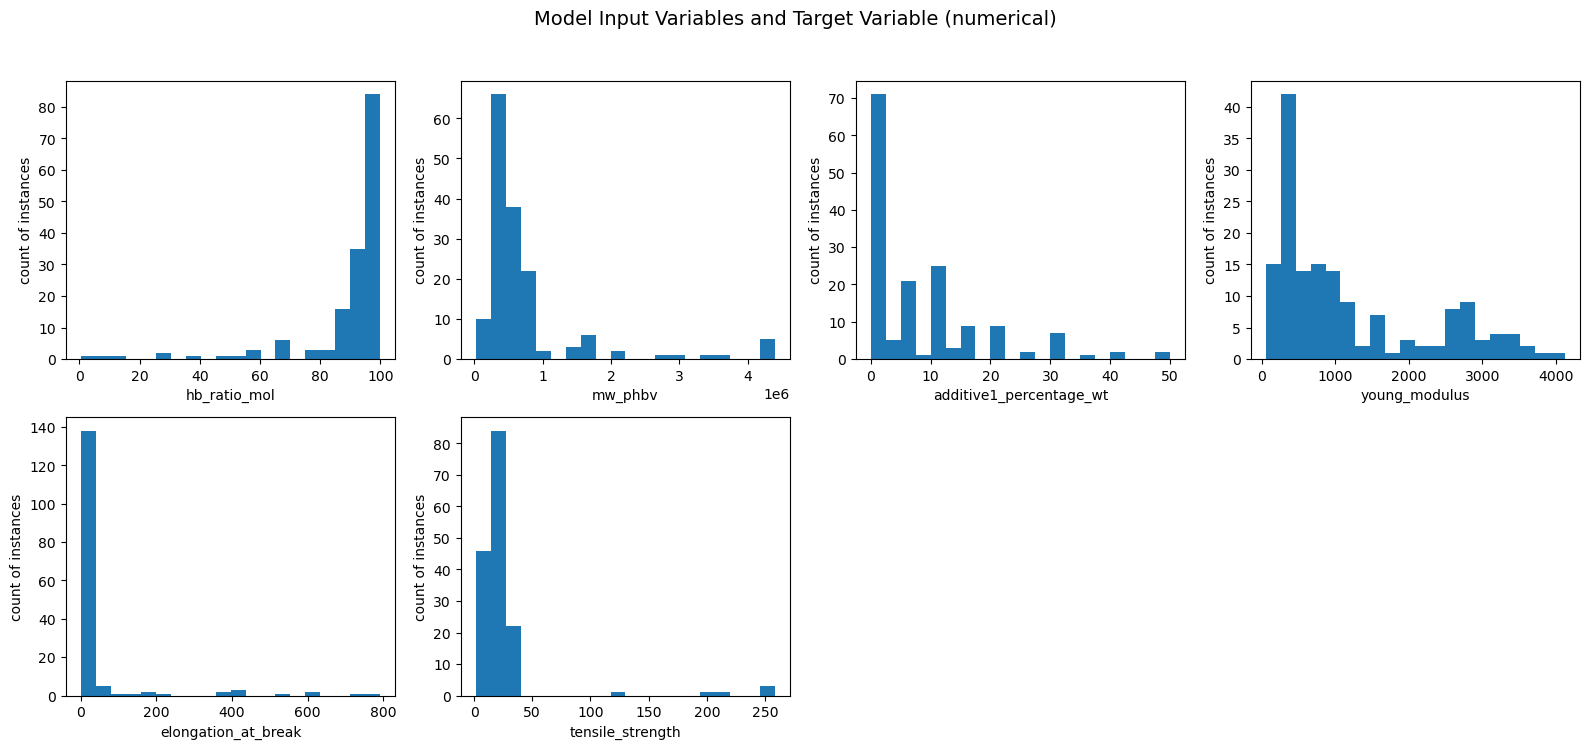

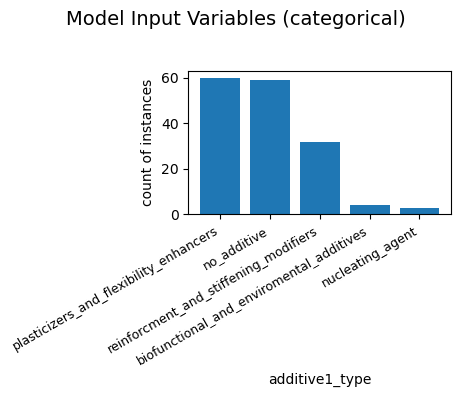

In [115]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

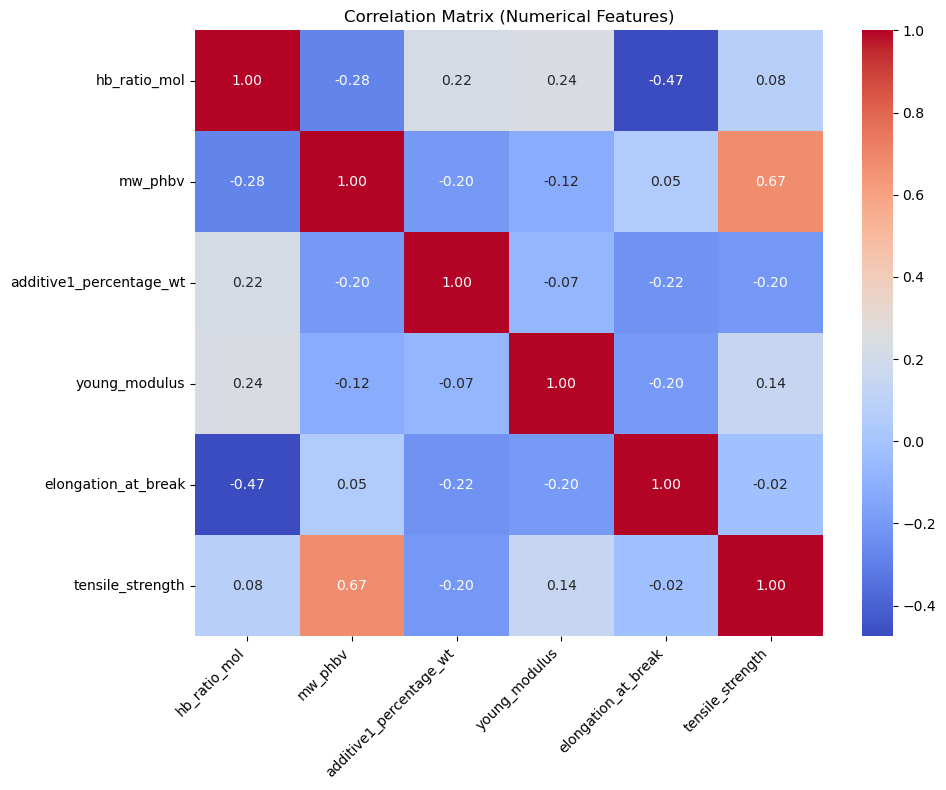

In [116]:
numerical_df = df_final[numerical_cols_lst]

# Compute correlation matrix
corr_matrix = numerical_df.corr() 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("young_correlation.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

In [117]:
df_final['tensile_strength'].describe()

count    158.000000
mean      25.930344
std       39.753744
min        1.450000
25%       13.032328
50%       20.050000
75%       25.000000
max      258.700000
Name: tensile_strength, dtype: float64

In [134]:
df_final['log_tensile'] = np.log1p(df_final['tensile_strength'])

## Train - test splitting

In [136]:
# Separate features and target
# drop_cols = [target]
drop_cols = [target,'tensile_strength','log_tensile']

X = df_final.drop(columns=drop_cols)
y = df_final['log_tensile']

In [137]:
X.columns

Index(['hb_ratio_mol', 'mw_phbv', 'additive1_type', 'additive1_percentage_wt',
       'young_modulus', 'elongation_at_break'],
      dtype='object')

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (126, 6) 
 Test set size (32, 6)


## FAMD for outlier detection - only on the Train set (if applied)

In [139]:
# Fit FAMD with a reasonably high number of components
famd = FAMD(n_components=20, n_iter=10, random_state=42).fit(X_train)

eigenvalues = famd.eigenvalues_
explained_inertia = eigenvalues / eigenvalues.sum()
cumulative_inertia = np.cumsum(explained_inertia)

famd.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,2.095,29.92%,29.92%
1,1.179,16.84%,46.77%
2,0.957,13.67%,60.44%
3,0.786,11.23%,71.67%
4,0.505,7.22%,78.89%
5,0.482,6.88%,85.77%
6,0.438,6.25%,92.02%
7,0.380,5.42%,97.44%
8,0.179,2.56%,100.00%


In [140]:
# Initial FAMD for outlier detection
n_components_initial = 8
famd2 = FAMD(n_components=n_components_initial, random_state=42)
X_train_famd = famd2.fit_transform(X_train)

X_train_famd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126 entries, 451 to 404
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       126 non-null    float64
 1   1       126 non-null    float64
 2   2       126 non-null    float64
 3   3       126 non-null    float64
 4   4       126 non-null    float64
 5   5       126 non-null    float64
 6   6       126 non-null    float64
 7   7       126 non-null    float64
dtypes: float64(8)
memory usage: 8.9 KB


In [141]:
X_train_famd_df = X_train_famd.copy()
X_train_famd_df.columns = [f'Comp{i+1}' for i in range(X_train_famd_df.shape[1])]

X_train_famd_df.tail()

,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6,Comp7,Comp8
278,0.711192,-0.477045,1.056835,0.951369,0.208548,-0.106888,-0.728289,-0.398594
408,3.709118,1.096831,-1.072109,-1.081554,-0.249805,0.283126,0.938875,0.026950
140,-0.296345,0.483582,0.327044,0.346524,-0.040528,-0.206377,-0.177223,-0.832280
367,-0.655245,0.127478,0.103164,0.198417,0.019566,-0.336986,-0.266807,-0.724933
404,-1.736239,0.176189,0.378976,-0.826115,-0.431156,0.078769,0.057590,1.944868


## Outlier detection with IQR

**Test = 1:** No exclusion
**Test = 2:** +-10 IQR   **Test = 3:** +-7 IQR  

In [142]:
test = 2

# Detect outliers using IQR
def detect_iqr_outliers(df,alpha):
    outlier_indices = set()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - alpha * IQR
        upper_bound = Q3 + alpha * IQR
        outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers_col)
    return list(outlier_indices)

# Drop outliers
if test == 2:
    alpha = 8
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±2")

elif test == 3:
    alpha = 7
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±",alpha)

else:
    df_clean = df_final.copy()
    X_train_clean = X_train
    y_train_clean = y_train
    print("IQR outlier detection SKIPPED")

print(f"Original data shape: {X_train.shape}")
print(f"Cleaned data shape: {X_train_clean.shape}")

IQR outlier detection APPLIED with ±2
Original data shape: (126, 6)
Cleaned data shape: (121, 6)


## One-hot encoding

In [143]:
X_train = X_train_clean.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)
ohe.fit(X_train[categorical_cols_lst])

# Transform
X_train_ohe = ohe.transform(X_train[categorical_cols_lst])
X_test_ohe = ohe.transform(X_test[categorical_cols_lst])

# Convert to DataFrame with proper column names
ohe_columns = ohe.get_feature_names_out(categorical_cols_lst)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

In [144]:
# combine
X_train_final = pd.concat([X_train.drop(columns=categorical_cols_lst), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols_lst), X_test_ohe_df], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (121, 8)
X_test_final shape: (32, 8)


## RF and XGBoost regression

In [145]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

xgb.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_xgb = xgb.predict(X_train_final)
y_test_pred_xgb = xgb.predict(X_test_final)


# Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_rf = rf.predict(X_train_final)
y_test_pred_rf = rf.predict(X_test_final)

In [146]:
y_test = y_test.copy()

def compute_metrics(y_true, y_pred):
    r,_ = pearsonr(y_true, y_pred)
    return {
        'R^2': r2_score(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

metrics = []

# XGBoost
train_xgb = compute_metrics(y_train_clean, y_train_pred_xgb)
test_xgb = compute_metrics(y_test, y_test_pred_xgb)

metrics.append([
    'XGBoost', 'Train',
    train_xgb['R^2'],
    train_xgb['RMSE'],
    train_xgb['MAE']
])

metrics.append([
    'XGBoost', 'Test',
    test_xgb['R^2'],
    test_xgb['RMSE'],
    test_xgb['MAE']
])

# Random Forest
train_rf = compute_metrics(y_train_clean, y_train_pred_rf)
test_rf  = compute_metrics(y_test, y_test_pred_rf)

metrics.append([
    'Random Forest', 'Train',
    train_rf['R^2'],
    train_rf['RMSE'],
    train_rf['MAE']
])

metrics.append([
    'Random Forest', 'Test',
    test_rf['R^2'],
    test_rf['RMSE'],
    test_rf['MAE']
])

In [147]:
metrics_df = pd.DataFrame(
    metrics,
    columns=['Model', 'Dataset', 'R^2', 'RMSE', 'MAE']
)

print(metrics_df)

           Model Dataset       R^2      RMSE       MAE
0        XGBoost   Train  0.999966  0.004505  0.003391
1        XGBoost    Test  0.830273  0.275057  0.204446
2  Random Forest   Train  0.966208  0.141274  0.088148
3  Random Forest    Test  0.803122  0.296241  0.208920


## Grid search - RF

In [150]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200], # 300],  # Number of trees in the forest
    'max_depth': [15, 20],  # Maximum depth of the tree
    'min_samples_split': [5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],
#    'max_features': ['sqrt', 0.5, 0.7], 
}

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search.fit(X_train_final, y_train_clean)

# Extract the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print
print(f"Best parameters found: {best_params}")
print(f"Best R^2 score from Grid Search (CV): {best_score}")

# Use the best estimator
best_rf = grid_search.best_estimator_

# Predictions
y_train_pred_grid = best_rf.predict(X_train_final)
y_test_pred_grid = best_rf.predict(X_test_final)

# Metrics
r2_train_grid = r2_score(y_train_clean, y_train_pred_grid)
r2_test_grid = r2_score(y_test, y_test_pred_grid)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid = cross_val_score(best_rf, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid = np.mean(cv_scores_r2_grid)
std_cv_r2_grid = np.std(cv_scores_r2_grid)

# Print
summary_df = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'Random Forest (Tuned)': [
        r2_train_grid,
        r2_test_grid,
        mean_cv_r2_grid,
        std_cv_r2_grid
    ]
})

print(summary_df)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=15, min_sa

## Plot results

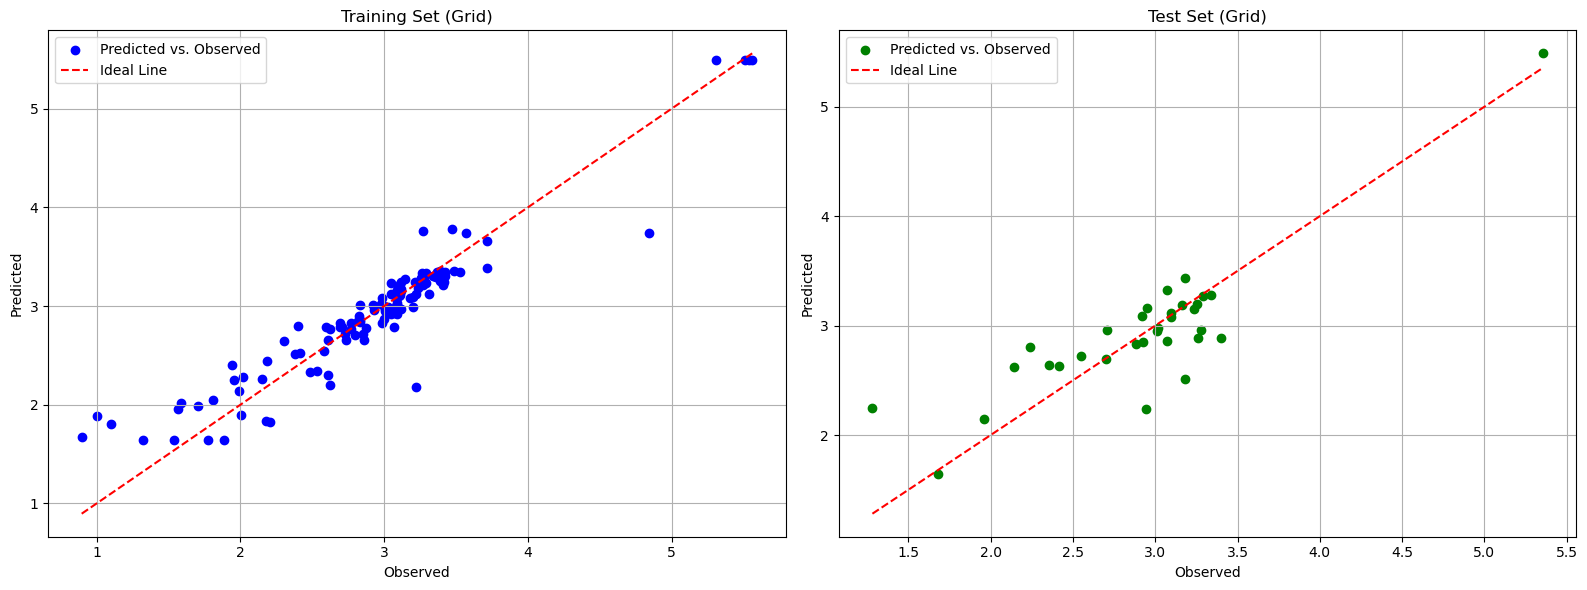

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set (Grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set (Grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("scl_tensile_rf_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Plot RMSE w.r.t No of trees

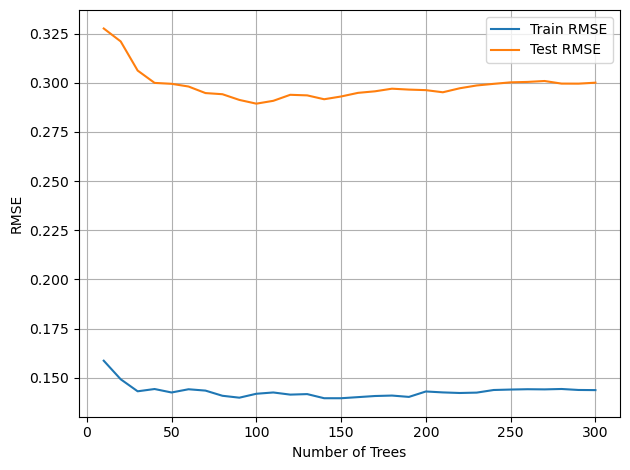

In [154]:
train_rmse = []
test_rmse = []

n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_final, y_train_clean)

    y_train_pred = rf.predict(X_train_final)
    y_test_pred = rf.predict(X_test_final)

    train_rmse.append(root_mean_squared_error(y_train_clean, y_train_pred))
    test_rmse.append(root_mean_squared_error(y_test, y_test_pred))

plt.figure()
plt.plot(n_estimators_range, train_rmse, label="Train RMSE")
plt.plot(n_estimators_range, test_rmse, label="Test RMSE")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("scl_tensile_rf_rmse.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [155]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

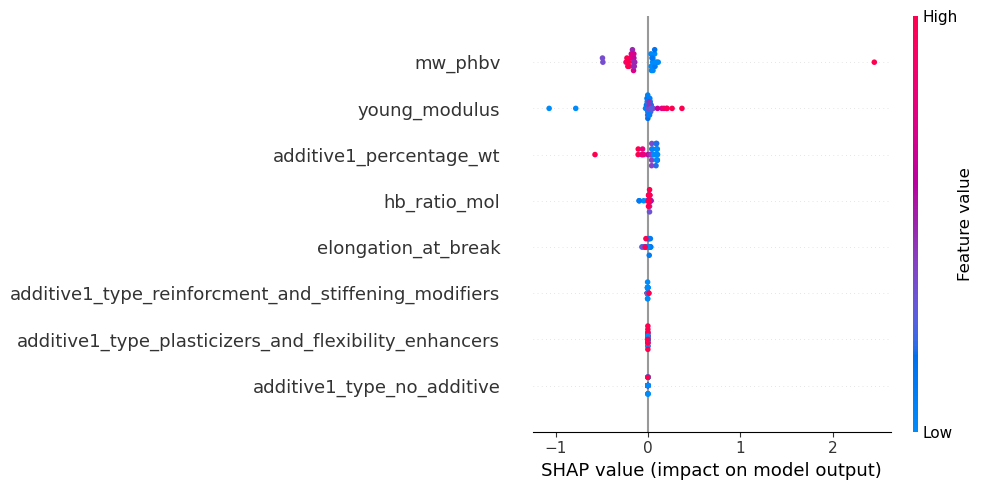

In [156]:
shap.summary_plot(
    shap_values,
    X_test_final,
#    max_display=5,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)

plt.tight_layout()
plt.savefig("scl_tensile_rf_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Grid search - XGBoost

In [152]:
# Define the parameter grid
param_grid = {
     'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05],
    'max_depth': [4, 6],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.5, 0.7],
     'min_child_weight': [5, 10],
    'reg_lambda': [5, 10]
}

# Initialize the Grid Search with Random Forest
grid_search2 = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search2.fit(X_train_final, y_train_clean)

# Extract the best parameters
best_params2 = grid_search2.best_params_
best_score2 = grid_search2.best_score_

# Print
print(f"Best parameters found: {best_params2}")
print(f"Best R^2 score from Grid Search (CV): {best_score2}")

# Use the best estimator
best_xgb = grid_search2.best_estimator_

# predictions
y_train_pred_grid2 = best_xgb.predict(X_train_final)
y_test_pred_grid2 = best_xgb.predict(X_test_final)

# Metrics
r2_train_grid2 = r2_score(y_train_clean, y_train_pred_grid2)
r2_test_grid2 = r2_score(y_test, y_test_pred_grid2)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid2 = cross_val_score(best_xgb, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid2 = np.mean(cv_scores_r2_grid2)
std_cv_r2_grid2 = np.std(cv_scores_r2_grid2)

# Print the R^2 scores
summary_df2 = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'XGBoost (Tuned)': [
        r2_train_grid2,
        r2_test_grid2,
        mean_cv_r2_grid2,
        std_cv_r2_grid2
    ]
})

print(summary_df2)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, min_child_weight=5, n_estimators=100, reg_lambda=5, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, min_child_weight=5, n_estimators=100, reg_lambda=5, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, min_child_weight=5, n_estimators=100, reg_lambda=5, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, min_child_weight=5, n_estimators=100, reg_lambda=5, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, min_child_weight=5, n_estimators=100, reg_lambda=5, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, min_child_weight=5, n_estimators=100, reg_lambda=5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.5, learni

## Plot results

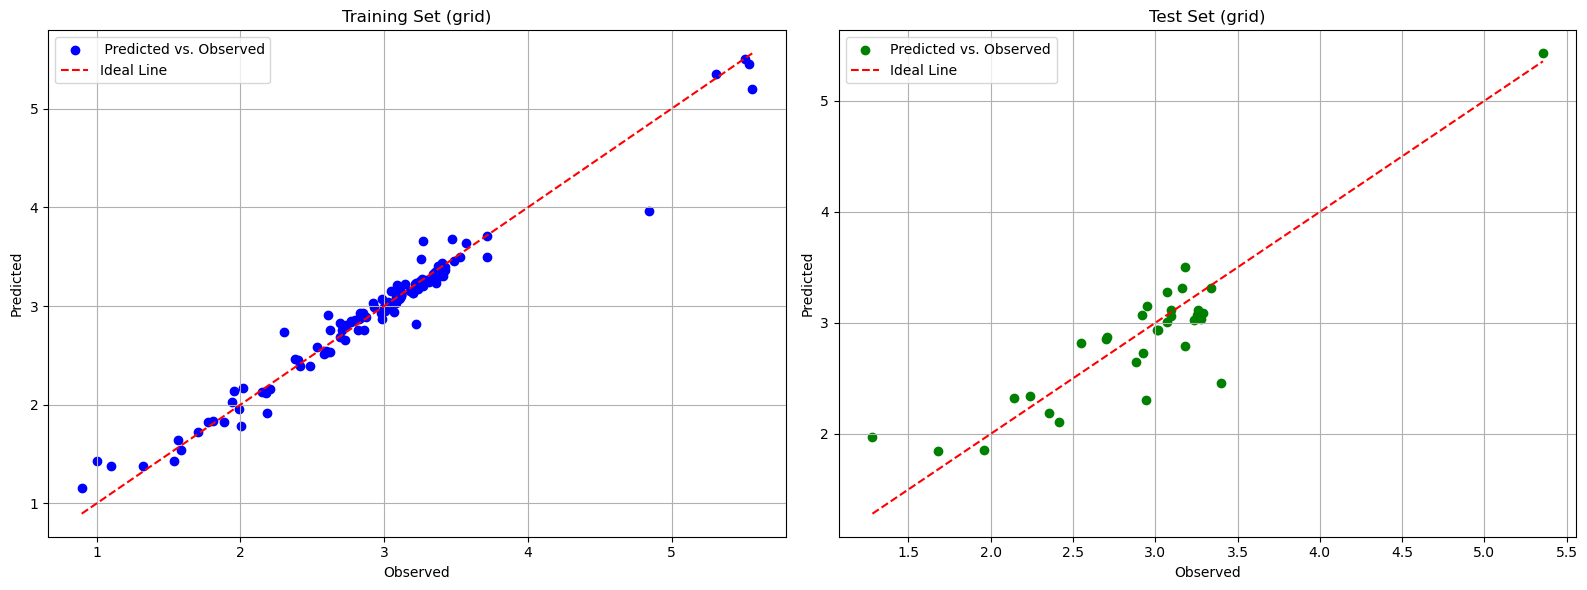

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid2, color='blue', label=' Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training Set (grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid2, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test Set (grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("scl_tensile_xg_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Loss plot

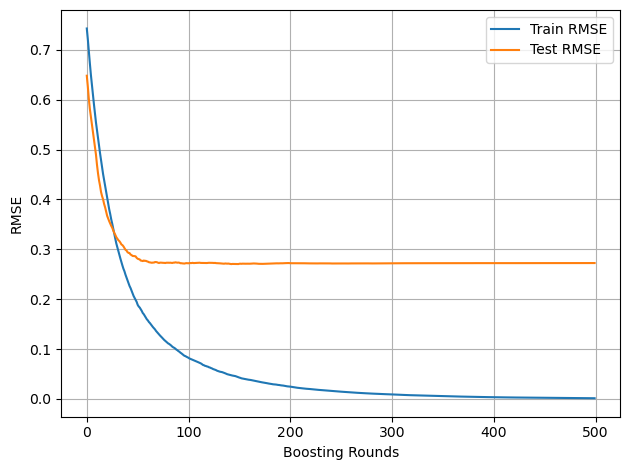

In [158]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=best_params2['max_depth'],
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["rmse"],
    random_state=42
)

model.fit(
    X_train_final, y_train_clean,
    eval_set=[(X_train_final, y_train_clean), (X_test_final, y_test)],
    verbose=False
)

results = model.evals_result()

epochs = len(results['validation_0']['rmse'])

plt.figure()
plt.plot(range(epochs), results['validation_0']['rmse'], label="Train RMSE")
plt.plot(range(epochs), results['validation_1']['rmse'], label="Test RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("scl_tensile_xg_loss.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [159]:
explainer2 = shap.TreeExplainer(best_xgb)
shap_values2 = explainer2.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value2 = explainer2.expected_value

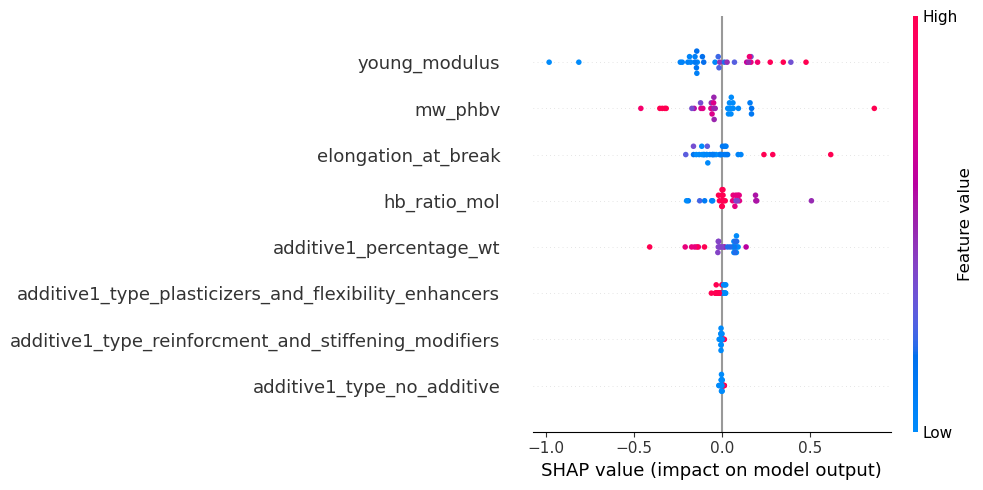

In [160]:
shap.summary_plot(
    shap_values2,
    X_test_final,
#    max_display=5,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)

plt.tight_layout()
plt.savefig("scl_tensile_xg_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
i = 2  # pick any row
shap.force_plot(base_value, shap_values[i, :], X_test_final.iloc[i, :], matplotlib=True)

# Jaqpot

In [187]:
df_ten.columns

Index(['hb_ratio_mol', 'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'pdi',
       'additive1_type', 'additive1_percentage_wt', 'additive2_type',
       'additive2_percentage_wt', 'spread_speed', 'young_modulus',
       'tensile_strength', 'elongation_at_break', 'tg1', 'tc1', 'tm1', 'td5',
       'dhm1', 'crystallinity'],
      dtype='object')

In [188]:
features = ['hb_ratio_mol', 
#            'hv_ratio_formulation', 
            'mw_phbv',
            'additive1_type', 
            'additive1_percentage_wt', 
#            'additive2_type',
 #           'additive2_percentage_wt', 
#            'spread_speed',
            'young_modulus', 
#            'tensile_strength', 
            'elongation_at_break', 
#            'tg1',
 #           'tc1',
#            'tm1',
  #          'td5',
   #         'crystallinity'
           ]

target = 'tensile_strength'

measure_unit = 'Mpa'

In [189]:
# Create DataFrame
df_new = df_ten[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]].copy()
df_final[target] = np.log10(df_final[target])  # log-transform
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

In [190]:
# Separate features and target
drop_cols = [target]

X = df_final.drop(columns=drop_cols)
y = df_final[target]

In [191]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (134, 6) 
 Test set size (24, 6)


In [192]:
numerical_cols_lst = (
    df_final
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_cols_lst = (
    df_final
    .select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

In [193]:
numerical_cols_lst.remove(target)
features_num = numerical_cols_lst
features_cat = categorical_cols_lst

In [194]:
df_train = X_train.copy()
df_train[target] = y_train

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

df_test = X_test.copy()
df_test[target] = y_test

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [195]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat)
    ],
    remainder='drop',
)

In [198]:
model = RandomForestRegressor(random_state=42, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300)
jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox(), MeanVar()],
    preprocess_x=preprocessing,
  )

jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'r2': 0.9692889835095463, 'mae': 0.0401132456685671, 'rmse': 0.061651735935187725}


In [199]:
from sklearn.base import clone

# Manually create what fit() should have set
jaqpot_model.unfit_pipeline = clone(jaqpot_model.pipeline)

# Now this should work
jaqpot_model.cross_validate(train_dataset, n_splits=10)

{'r2': 0.7079577416197362,
 'mae': 0.1226509188940296,
 'rmse': 0.17397935938404643}

In [200]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'r2': 0.782131960988308,
 'mae': 0.10519252855187289,
 'rmse': 0.1495959463633018}

In [201]:
# Conducts a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'r2': 0.8531999027306248,
   'mae': 0.09887493332109201,
   'rmse': 0.13479115218750296},
  'Test': {'r2': -0.4408974174566209,
   'mae': 0.2518873027623361,
   'rmse': 0.38471542081227067}},
 'iteration_1': {'Train': {'r2': 0.8231801222369248,
   'mae': 0.10277723468775962,
   'rmse': 0.1479325545919065},
  'Test': {'r2': 0.2919632432273541,
   'mae': 0.16939045673763856,
   'rmse': 0.2696813821555394}},
 'iteration_2': {'Train': {'r2': 0.8234571208272332,
   'mae': 0.1030024598807973,
   'rmse': 0.14781663671423867},
  'Test': {'r2': -0.010649381459366891,
   'mae': 0.22614730696428365,
   'rmse': 0.32219835632600696}},
 'iteration_3': {'Train': {'r2': 0.8384135019323816,
   'mae': 0.10008169492845614,
   'rmse': 0.14141671622117144},
  'Test': {'r2': 0.06829507436312654,
   'mae': 0.2132796372064083,
   'rmse': 0.30935864655846324}},
 'iteration_4': {'Train': {'r2': 0.8506754048601849,
   'mae': 0.10225947372267576,
   'rmse': 0.13594520280860325},
  'Test

In [202]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)
print(doa_predictions)

{'LEVERAGE': [{'h': 0.042201574525315325, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.1612078695422409, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.043979926917709494, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.5040625368273334, 'hStar': 0.2462686567164179, 'inDoa': False}, {'h': 0.05748526262734334, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.03360378946972827, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.03240760770408344, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.03213164020985619, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.041628855873191234, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.03370173274482305, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.3412720066341865, 'hStar': 0.2462686567164179, 'inDoa': False}, {'h': 0.035482102299395996, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.037012869751635896, 'hStar': 0.2462686567164179, 'inDoa': True}, {'h': 0.11557428445111748, 'hStar': 0.24626865

In [203]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 24, 'n_in': 22, 'n_out': 2},
 'BOUNDING_BOX': {'n_total': 24, 'n_in': 24, 'n_out': 0}}

In [204]:
# Upload the pretrained model on Jaqpot
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Tensile strength regression model for scl-PHAs A.N.I.P.H.",
    description="Prediction of Tensile strength for scl-PHAs.",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-07-23 10:23:33,018 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2401


In [205]:
df_train[features_num].agg(['min','max'])

,hb_ratio_mol,mw_phbv,additive1_percentage_wt,young_modulus,elongation_at_break
min,0.5,23900.0,0.0,54.7,0.4
max,100.0,4400000.0,50.0,4124.0,792.0
